# Pendulum Dataset — Load & Visualise

This notebook explains what the pendulum dataset is, loads it, and plots labelled examples.


## What is this dataset?

Each sample is a **synthetic image** of a pendulum scene containing:
- A **pendulum** hanging from a fixed suspension point at (10, 10.5)
- A **sun / light source** at a fixed height (y=20.5) but variable horizontal position
- A **shadow** cast by the pendulum onto a ground plane (y=−0.5)

### Concepts (inputs to explain the image)
| Name | Meaning |
|------|---------|
| `theta` | Angle of the pendulum (radians). 0 = vertical, positive = right |
| `phi`   | Angle of the light source (radians). Controls shadow direction |

### Task label (what a model should predict)
| Name | Meaning |
|------|--------|
| `pendulum_x` | x-coordinate of the pendulum ball tip |

The idea is to test whether a model can learn the task *through* the interpretable concepts (theta, phi).


In [9]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

path = os.path.abspath("..")

PENDULUM_DIR = '/Users/yassine/Desktop/CBMC/CBMC/data/generated/pendulum'

CONCEPT_NAMES = ['theta', 'phi']
TASK_NAMES    = ['pendulum_x']
ALL_COLS      = ['img_dir'] + CONCEPT_NAMES + TASK_NAMES


## 1. Load the pickled DataFrames

In [10]:
train_df = pd.read_pickle(f'{PENDULUM_DIR}/train/train_df.pkl')
val_df   = pd.read_pickle(f'{PENDULUM_DIR}/val/val_df.pkl')
test_df  = pd.read_pickle(f'{PENDULUM_DIR}/test/test_df.pkl')

print(f'Train : {len(train_df):>7,} samples')
print(f'Val   : {len(val_df):>7,} samples')
print(f'Test  : {len(test_df):>7,} samples')
print()
train_df[ALL_COLS].head()


Train :  70,000 samples
Val   :  10,000 samples
Test  :  20,000 samples



,img_dir,theta,phi,pendulum_x
0,./data/generated/pendulum/train/a_-200.0_60.24...,-3.141593,0.946251,10.0
1,./data/generated/pendulum/train/a_-200.0_60.32...,-3.141593,0.947509,10.0
2,./data/generated/pendulum/train/a_-200.0_60.40...,-3.141593,0.948767,10.0
3,./data/generated/pendulum/train/a_-200.0_60.48...,-3.141593,0.950025,10.0
4,./data/generated/pendulum/train/a_-200.0_60.56...,-3.141593,0.951283,10.0


In [16]:
print(train_df.head())

                                             img_dir     theta       phi  \
0  ./data/generated/pendulum/train/a_-200.0_60.24... -3.141593  0.946251   
1  ./data/generated/pendulum/train/a_-200.0_60.32... -3.141593  0.947509   
2  ./data/generated/pendulum/train/a_-200.0_60.40... -3.141593  0.948767   
3  ./data/generated/pendulum/train/a_-200.0_60.48... -3.141593  0.950025   
4  ./data/generated/pendulum/train/a_-200.0_60.56... -3.141593  0.951283   

  pendulum_x  suspension_x  suspension_y  pendulum_length  pendulum_y  ball_x  \
0       10.0          10.0          10.5              8.0        18.5    10.0   
1       10.0          10.0          10.5              8.0        18.5    10.0   
2       10.0          10.0          10.5              8.0        18.5    10.0   
3       10.0          10.0          10.5              8.0        18.5    10.0   
4       10.0          10.0          10.5              8.0        18.5    10.0   

   ball_y    light_x  light_y  shade_plane  shade_length

## 2. Concept & label distributions

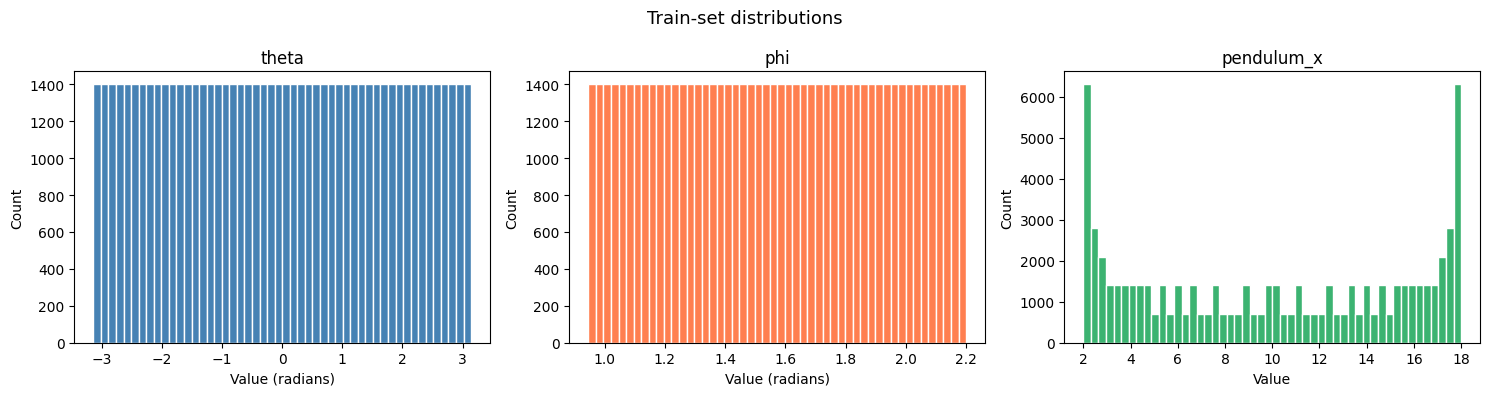

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, col, color in zip(axes, ['theta', 'phi', 'pendulum_x'], colors):
    ax.hist(train_df[col], bins=50, color=color, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value (radians)' if col in ['theta','phi'] else 'Value')
    ax.set_ylabel('Count')

plt.suptitle('Train-set distributions', fontsize=13)
plt.tight_layout()
plt.show()


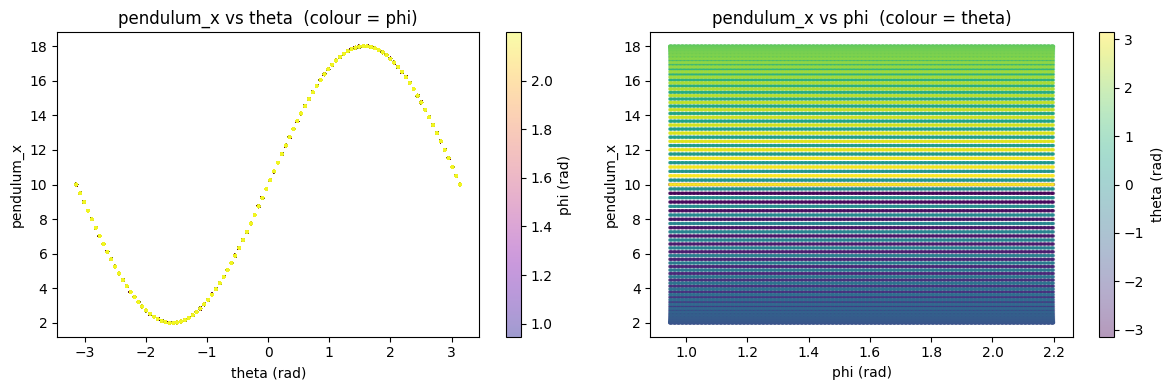

In [12]:
# Scatter: how theta and phi jointly determine pendulum_x
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sc1 = axes[0].scatter(train_df['theta'], train_df['pendulum_x'],
                      c=train_df['phi'], cmap='plasma', s=2, alpha=0.4)
axes[0].set_xlabel('theta (rad)')
axes[0].set_ylabel('pendulum_x')
axes[0].set_title('pendulum_x vs theta  (colour = phi)')
plt.colorbar(sc1, ax=axes[0], label='phi (rad)')

sc2 = axes[1].scatter(train_df['phi'], train_df['pendulum_x'],
                      c=train_df['theta'], cmap='viridis', s=2, alpha=0.4)
axes[1].set_xlabel('phi (rad)')
axes[1].set_ylabel('pendulum_x')
axes[1].set_title('pendulum_x vs phi  (colour = theta)')
plt.colorbar(sc2, ax=axes[1], label='theta (rad)')

plt.tight_layout()
plt.show()


## 3. Visualise labelled examples

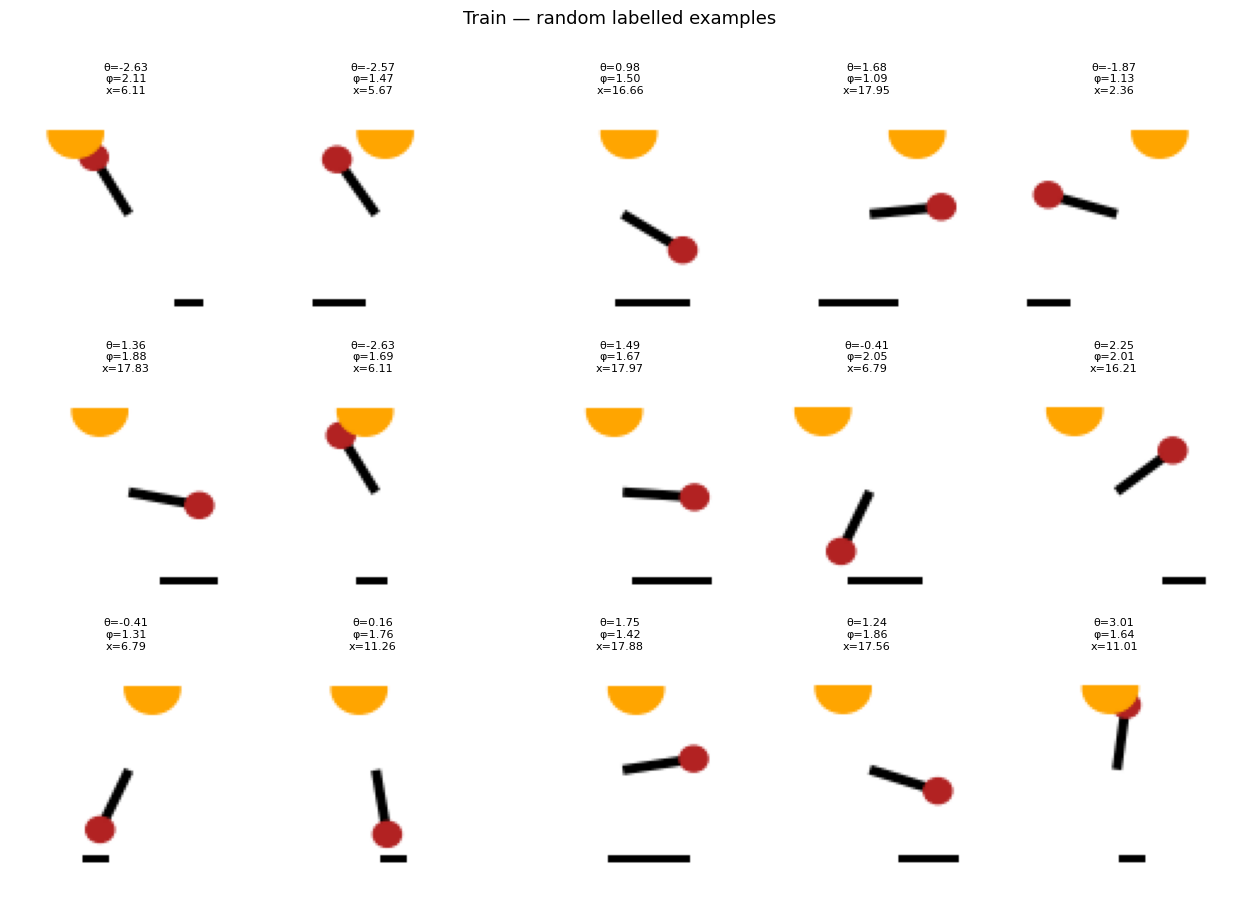

In [15]:
def show_samples(df, n_rows=3, n_cols=5, title='Samples', seed=42):
    """Plot n_rows × n_cols random images with their concept & task labels."""
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(df), size=n_rows * n_cols, replace=False)
    subset  = df.iloc[indices].reset_index(drop=True)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 3))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open("/Users/yassine/Desktop/CBMC/CBMC/"+row['img_dir']).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f"θ={row['theta']:.2f}\n"
            f"φ={row['phi']:.2f}\n"
            f"x={row['pendulum_x']:.2f}",
            fontsize=8
        )

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

show_samples(train_df, n_rows=3, n_cols=5, title='Train — random labelled examples')


## 4. Sweep theta (phi fixed) — see how the ball moves

FileNotFoundError: [Errno 2] No such file or directory: './data/generated/pendulum/train/a_-200.0_97.8779_3.0_9.4748.png'

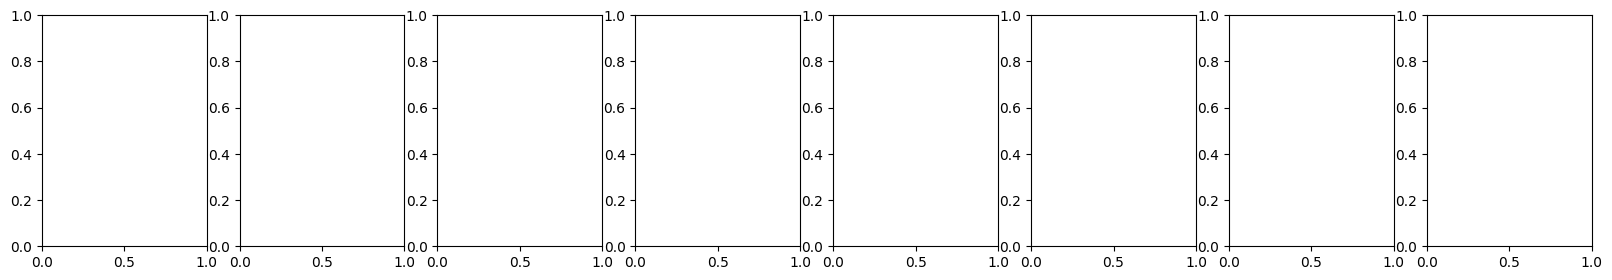

In [14]:
# Fix phi close to its median, sweep theta across its range
phi_median = train_df['phi'].median()
phi_tol    = (train_df['phi'].max() - train_df['phi'].min()) * 0.03

fixed_phi = train_df[np.abs(train_df['phi'] - phi_median) < phi_tol].copy()
fixed_phi = fixed_phi.sort_values('theta')

# Pick 8 evenly spaced rows
idx  = np.linspace(0, len(fixed_phi)-1, 8, dtype=int)
rows = fixed_phi.iloc[idx]

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, (_, row) in zip(axes, rows.iterrows()):
    img = Image.open(row['img_dir']).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"θ={row['theta']:.2f}\nx={row['pendulum_x']:.2f}", fontsize=8)

plt.suptitle(f'Sweeping theta  |  phi ≈ {phi_median:.2f} (fixed)', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Sweep phi (theta fixed) — see how the shadow moves

In [ ]:
# Fix theta close to 0 (vertical pendulum), sweep phi
theta_tol  = (train_df['theta'].max() - train_df['theta'].min()) * 0.03
fixed_theta = train_df[np.abs(train_df['theta']) < theta_tol].copy()
fixed_theta = fixed_theta.sort_values('phi')

idx  = np.linspace(0, len(fixed_theta)-1, 8, dtype=int)
rows = fixed_theta.iloc[idx]

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, (_, row) in zip(axes, rows.iterrows()):
    img = Image.open(row['img_dir']).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"φ={row['phi']:.2f}\nx={row['pendulum_x']:.2f}", fontsize=8)

plt.suptitle('Sweeping phi  |  theta ≈ 0 (vertical pendulum)', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Summary statistics

In [ ]:
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'── {name} ──────────────────────────────')
    print(df[CONCEPT_NAMES + TASK_NAMES].describe().round(3).to_string())
    print()


## 7. Load via DataLoader (ready for training)

In [ ]:
# make sure pendulum.py (the original file) is importable
sys.path.append('.')
from pendulum import PendulumDataset

loader = PendulumDataset(already_created=True, batch_size=32)
train_loader, val_loader, test_loader = loader.collator()

batch = next(iter(train_loader))
print('x (images) :', batch['x'].shape)   # (32, 3, H, W)
print('c (concepts):', batch['c'].shape)  # (32, 2)  → [theta, phi]
print('y (task)    :', batch['y'].shape)  # (32,)    → pendulum_x
print()
print('Concept sample (first 5 rows):')
print(pd.DataFrame(batch['c'].numpy(), columns=['theta','phi']).head())
print('\nTask label sample:', batch['y'][:5].tolist())
